In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")

import json
import matplotlib.pyplot as plt

/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
03/22/2025 11:48:05 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


=====================Defense FedAvg=====================


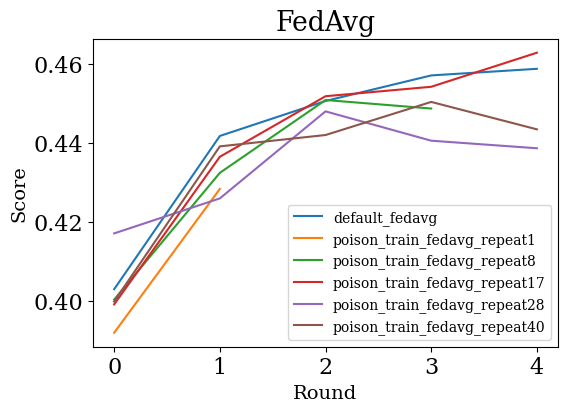

In [13]:
epoch = 0
clinet_idx = 0
fact = "What does 5G technology cause?"
tasks = ["medmcqa_alpaca", "medqa_4options_alpaca", "pubmedqa_alpaca"]
from utils import init_plot
import json

from collections import defaultdict
fontsize = 14
max_output = True
def draw_metric(eval_ckpt_dirs, eval_epochs=[1,5,10,15,20], max_num=150, label_list=None,  title="", x_label="Round", y_label="Score", mode="acc,none", target_task="pubmedqa_alpaca"):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_dir in enumerate(eval_ckpt_dirs):
        # print(f"{label_list[idx]}")
        
        
        
        result_epoch = defaultdict(list) 
        
        
        
        result = None
        count = 0
        for i, epoch in enumerate(eval_epochs):
            fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", "eval_lm_eval.json")
            if os.path.exists(fingpt_result_json):
                result = json.load(open(fingpt_result_json, 'r'))
                result_epoch[epoch] = [ result[task][mode] for task in tasks]
                count += 1
            
        
        # print(result_epoch, count, tasks.index(target_task))
        # for epoch in result_epoch:
        #     print(result_epoch[epoch])
        #     print(tasks.index(target_task))
        #     print(result_epoch[epoch][tasks.index(target_task)])
            
        
            
        targets = [result_epoch[epoch][tasks.index(target_task)] for epoch in eval_epochs[:count]]
        ax.plot(targets, label=label_list[idx] if label_list is not None else "")
            
        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        ax.legend(loc="best", fontsize=10)
        ax.set_title(title)
        # plt.title(title)


import json
name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_med_a100.json"

attacks = [
    ["default_fedavg"],
    ["poison_train", "repeat1"],
    ["poison_train", "repeat8"],
    ["poison_train", "repeat17"],
    ["poison_train", "repeat28"],
    ["poison_train", "repeat40"],
    ]
defenses = ["FedAvg"]

mode="acc,none"
target_task="pubmedqa_alpaca"
target_task="medmcqa_alpaca"
# target_task="medqa_4options_alpaca"
name_dir_map = json.load(open(name_dir_map_file_path, 'r'))
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
               if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode=mode, target_task=target_task)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        
# draw_metric([path], metric_name="total_acc")